### Generate ROC Curves

**Reasoning**:
I will generate ROC curves for each of the models (Logistic Regression, Random Forest, and Gradient Boosting) for both the 'pure' and 'hybrid' datasets. This involves calculating the False Positive Rate (FPR), True Positive Rate (TPR), and Area Under the Curve (AUC) for each model's predictions on its respective test set. The `roc_curve` and `roc_auc_score` functions from `sklearn.metrics` will be used to obtain these values, and `matplotlib.pyplot` will be used for plotting the curves. This will provide a clear visual comparison of how well each model distinguishes between the two classes in both scenarios.

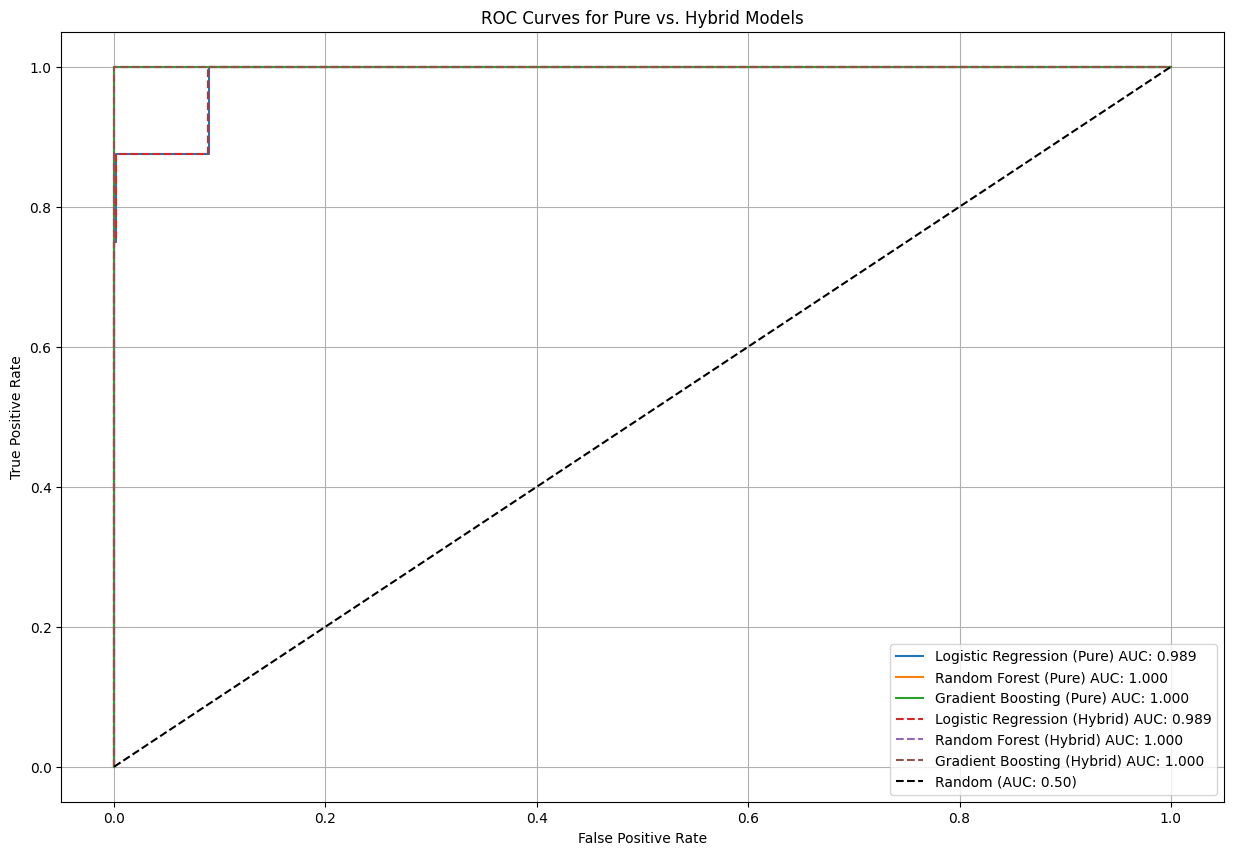

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Plot ROC curves for Pure Models
for name, model in models.items():
    # For pure models
    model.fit(X_train_pure, y_train_pure)
    y_pred_proba_pure = model.predict_proba(X_test_pure)[:, 1]
    fpr_pure, tpr_pure, _ = roc_curve(y_test_pure, y_pred_proba_pure)
    plt.plot(fpr_pure, tpr_pure, label=f'{name} (Pure) AUC: {roc_auc_score(y_test_pure, y_pred_proba_pure):.3f}', linestyle='-')

# Plot ROC curves for Hybrid Models
for name, model in models.items():
    # For hybrid models
    model.fit(X_train_hybrid_resampled, y_train_hybrid_resampled)
    y_pred_proba_hybrid = model.predict_proba(X_test_hybrid)[:, 1]
    fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_hybrid, y_pred_proba_hybrid)
    plt.plot(fpr_hybrid, tpr_hybrid, label=f'{name} (Hybrid) AUC: {roc_auc_score(y_test_hybrid, y_pred_proba_hybrid):.3f}', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC: 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Pure vs. Hybrid Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Task
Compare the performance of supervised models (Random Forest, Logistic Regression, and Gradient Boosting) for credit card fraud detection, both with and without incorporating anomaly scores from Isolation Forest as a feature. Use the first 10,000 rows of the "creditcard.csv" dataset, address class imbalance, evaluate models using Precision, Recall, F1-score, and ROC-AUC, visualize the comparison, and provide insights into the effectiveness of the hybrid approach.

## Load and Preprocess Data

### Subtask:
Load the 'creditcard.csv' dataset using pandas, selecting only the first 10,000 rows as requested. Separate features (X) from the target variable (y). Perform any necessary basic preprocessing such as handling missing values, if any are present.


**Reasoning**:
First, I'll import the pandas library, then load the 'creditcard.csv' dataset, select the first 10,000 rows, separate features (X) from the target variable (y), and finally check for any missing values in both X and y. This directly addresses all the instructions in the current subtask.



In [ ]:
import pandas as pd

# Load the 'creditcard.csv' dataset
df = pd.read_csv('/content/creditcard.csv')

# Select the first 10,000 rows
df = df.head(10000)
print("DataFrame loaded and trimmed to first 10,000 rows:")
print(df.head())

# Separate features (X) from the target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

print("\nShape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Check for missing values in X and y
print("\nMissing values in features (X):")
print(X.isnull().sum())

print("\nMissing values in target (y):")
print(y.isnull().sum())

## Handle Class Imbalance

### Subtask:
Address the class imbalance in the training data using a suitable technique like SMOTE (Synthetic Minority Over-sampling Technique) or undersampling to create a balanced dataset for supervised learning.


**Reasoning**:
To address class imbalance, I will first split the data into training and testing sets, then apply SMOTE to the training data, and finally print the class distributions to demonstrate the balancing effect. This requires importing `train_test_split` and `SMOTE`.



In [1]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Split the dataset (X and y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Original dataset shape:", Counter(y))
print("Training dataset shape (before SMOTE):", Counter(y_train))
print("Test dataset shape:", Counter(y_test))

# 2. Apply SMOTE to the training data only
smote = SMOTE(random_state=42)

# 3. Fit and transform the training features (X_train) and target (y_train)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 4. Print the class distribution
print("\nResampled training dataset shape (after SMOTE):", Counter(y_resampled))

NameError: name 'X' is not defined

**Reasoning**:
The `NameError: name 'X' is not defined` indicates that the variables `X` and `y` were not available in the kernel when the current cell was executed. Based on the provided notebook, `X` and `y` are defined in an earlier cell. To fix this, I will re-include the necessary code from the previous cell to load the data and define `X` and `y` before performing the train-test split and SMOTE operations in this cell, ensuring the necessary variables are present.



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Re-load data and define X, y as they were not found in the current kernel state
# Load the 'creditcard.csv' dataset
df = pd.read_csv('/content/creditcard.csv')

# Select the first 10,000 rows
df = df.head(10000)

# Separate features (X) from the target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 1. Split the dataset (X and y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Original dataset shape:", Counter(y))
print("Training dataset shape (before SMOTE):", Counter(y_train))
print("Test dataset shape:", Counter(y_test))

# 2. Apply SMOTE to the training data only
smote = SMOTE(random_state=42)

# 3. Fit and transform the training features (X_train) and target (y_train)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 4. Print the class distribution
print("\nResampled training dataset shape (after SMOTE):", Counter(y_resampled))

Original dataset shape: Counter({0: 9962, 1: 38})
Training dataset shape (before SMOTE): Counter({0: 7970, 1: 30})
Test dataset shape: Counter({0: 1992, 1: 8})

Resampled training dataset shape (after SMOTE): Counter({0: 7970, 1: 7970})


## Unsupervised Anomaly Detection (Isolation Forest)

### Subtask:
Apply an unsupervised anomaly detection algorithm, specifically Isolation Forest, to the original dataset. Generate anomaly scores for each data point. These scores will be used as additional features for the hybrid models.


**Reasoning**:
I will import `IsolationForest`, instantiate the model with appropriate parameters including `contamination` based on the observed class imbalance, fit it to the original feature set `X`, predict anomaly scores, and then add these scores as a new column to `X` to fulfill the subtask requirements.



In [3]:
from sklearn.ensemble import IsolationForest

# Instantiate IsolationForest model
# Set contamination based on the proportion of minority class in the original dataset (38 out of 10000 = 0.0038)
isolation_forest = IsolationForest(random_state=42, contamination=0.004)

# Fit the Isolation Forest model to the original features X
isolation_forest.fit(X)

# Predict the anomaly scores for the original features X
anomaly_scores = isolation_forest.decision_function(X)

# Add the generated anomaly scores as a new column named 'anomaly_score' to the original features DataFrame X
X['anomaly_score'] = anomaly_scores

print("Isolation Forest applied and anomaly scores generated.")
print("First 5 rows of X with new 'anomaly_score' column:")
print(X.head())

Isolation Forest applied and anomaly scores generated.
First 5 rows of X with new 'anomaly_score' column:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.27

## Prepare Datasets for Supervised Learning

### Subtask:
Create two sets of datasets for supervised learning: one 'pure' dataset (the balanced dataset from handling imbalance) and one 'hybrid' dataset (the balanced dataset with the Isolation Forest anomaly scores added as a new feature).


**Reasoning**:
I will define the 'pure' datasets by assigning the already processed `X_resampled`, `y_resampled`, `X_test`, and `y_test` variables. Then, I will create the 'hybrid' datasets by splitting the `X` dataframe (which now includes the 'anomaly_score') and `y` into training and testing sets, and subsequently applying SMOTE to the hybrid training set.



In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Define the 'pure' training and testing datasets
X_train_pure = X_resampled
y_train_pure = y_resampled
X_test_pure = X_test
y_test_pure = y_test

print("--- Pure Datasets ---")
print("Shape of X_train_pure:", X_train_pure.shape)
print("Shape of y_train_pure:", y_train_pure.shape)
print("Shape of X_test_pure:", X_test_pure.shape)
print("Shape of y_test_pure:", y_test_pure.shape)
print("Class distribution of y_train_pure:", Counter(y_train_pure))
print("Class distribution of y_test_pure:", Counter(y_test_pure))

# 2. Create the 'hybrid' training and testing datasets
# X now contains the 'anomaly_score' column
X_train_hybrid_raw, X_test_hybrid, y_train_hybrid_raw, y_test_hybrid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Hybrid Raw Datasets (before SMOTE) ---")
print("Shape of X_train_hybrid_raw:", X_train_hybrid_raw.shape)
print("Shape of y_train_hybrid_raw:", y_train_hybrid_raw.shape)
print("Shape of X_test_hybrid:", X_test_hybrid.shape)
print("Shape of y_test_hybrid:", y_test_hybrid.shape)
print("Class distribution of y_train_hybrid_raw:", Counter(y_train_hybrid_raw))
print("Class distribution of y_test_hybrid:", Counter(y_test_hybrid))

# 3. Apply SMOTE to the X_train_hybrid_raw and y_train_hybrid_raw
smote_hybrid = SMOTE(random_state=42)
X_train_hybrid_resampled, y_train_hybrid_resampled = smote_hybrid.fit_resample(X_train_hybrid_raw, y_train_hybrid_raw)

print("\n--- Hybrid Resampled Training Dataset (after SMOTE) ---")
print("Shape of X_train_hybrid_resampled:", X_train_hybrid_resampled.shape)
print("Shape of y_train_hybrid_resampled:", y_train_hybrid_resampled.shape)
print("Class distribution of y_train_hybrid_resampled:", Counter(y_train_hybrid_resampled))

--- Pure Datasets ---
Shape of X_train_pure: (15940, 30)
Shape of y_train_pure: (15940,)
Shape of X_test_pure: (2000, 30)
Shape of y_test_pure: (2000,)
Class distribution of y_train_pure: Counter({0: 7970, 1: 7970})
Class distribution of y_test_pure: Counter({0: 1992, 1: 8})

--- Hybrid Raw Datasets (before SMOTE) ---
Shape of X_train_hybrid_raw: (8000, 31)
Shape of y_train_hybrid_raw: (8000,)
Shape of X_test_hybrid: (2000, 31)
Shape of y_test_hybrid: (2000,)
Class distribution of y_train_hybrid_raw: Counter({0: 7970, 1: 30})
Class distribution of y_test_hybrid: Counter({0: 1992, 1: 8})

--- Hybrid Resampled Training Dataset (after SMOTE) ---
Shape of X_train_hybrid_resampled: (15940, 31)
Shape of y_train_hybrid_resampled: (15940,)
Class distribution of y_train_hybrid_resampled: Counter({0: 7970, 1: 7970})


## Train and Evaluate Pure Supervised Models

### Subtask:
Train and evaluate supervised classification models (Random Forest, Logistic Regression, and Gradient Boosting) on the 'pure' balanced dataset. Evaluate each model using Precision, Recall, F1-score, and ROC-AUC.


**Reasoning**:
I will import the necessary classification models and metrics, initialize and train each model on the 'pure' balanced dataset, predict on the test set, calculate and store the specified evaluation metrics (Precision, Recall, F1-score, ROC-AUC) for each model, and finally print the results. This directly addresses all instructions for evaluating pure supervised models.



In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize an empty dictionary to store results
pure_model_results = {}

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("Evaluating Pure Supervised Models...")

for name, model in models.items():
    print(f"\n--- Training and evaluating {name} (Pure Dataset) ---")

    # a. Fit the model to the pure resampled training data
    model.fit(X_train_pure, y_train_pure)

    # b. Make predictions on the pure test data
    y_pred = model.predict(X_test_pure)
    y_pred_proba = model.predict_proba(X_test_pure)[:, 1] # Probability for the positive class (class 1)

    # c. Calculate Precision, Recall, F1-score
    report = classification_report(y_test_pure, y_pred, output_dict=True)

    # Extract metrics for the positive class (class 1)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1_score = report['1']['f1-score']

    # d. Calculate ROC-AUC
    roc_auc = roc_auc_score(y_test_pure, y_pred_proba)

    # e. Store these metrics in the dictionary
    pure_model_results[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1_score,
        'ROC-AUC': roc_auc
    }

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1_score:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

# Print the pure_model_results dictionary
print("\n--- Pure Model Evaluation Results ---")
import json
print(json.dumps(pure_model_results, indent=4))

Evaluating Pure Supervised Models...

--- Training and evaluating Logistic Regression (Pure Dataset) ---
Precision: 0.5385
Recall: 0.8750
F1-score: 0.6667
ROC-AUC: 0.9886

--- Training and evaluating Random Forest (Pure Dataset) ---
Precision: 1.0000
Recall: 0.8750
F1-score: 0.9333
ROC-AUC: 1.0000

--- Training and evaluating Gradient Boosting (Pure Dataset) ---
Precision: 1.0000
Recall: 0.8750
F1-score: 0.9333
ROC-AUC: 1.0000

--- Pure Model Evaluation Results ---
{
    "Logistic Regression": {
        "Precision": 0.5384615384615384,
        "Recall": 0.875,
        "F1-score": 0.6666666666666666,
        "ROC-AUC": 0.9886420682730923
    },
    "Random Forest": {
        "Precision": 1.0,
        "Recall": 0.875,
        "F1-score": 0.9333333333333333,
        "ROC-AUC": 1.0
    },
    "Gradient Boosting": {
        "Precision": 1.0,
        "Recall": 0.875,
        "F1-score": 0.9333333333333333,
        "ROC-AUC": 1.0
    }
}


## Train and Evaluate Hybrid Supervised Models

### Subtask:
Train and evaluate the same supervised classification models (Random Forest, Logistic Regression, and Gradient Boosting) on the 'hybrid' dataset (including anomaly scores as a feature). Evaluate each model using Precision, Recall, F1-score, and ROC-AUC.


**Reasoning**:
I will initialize an empty dictionary, then iterate through the defined models, fitting each to the hybrid resampled training data and evaluating its performance on the hybrid test data using precision, recall, F1-score, and ROC-AUC, storing the results, and finally printing them to fulfill the subtask.



In [6]:
import json

# 1. Initialize an empty dictionary to store results
hybrid_model_results = {}

# Models are already defined from the previous step:
# models = {
#     'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
#     'Random Forest': RandomForestClassifier(random_state=42),
#     'Gradient Boosting': GradientBoostingClassifier(random_state=42)
# }

print("Evaluating Hybrid Supervised Models...")

for name, model in models.items():
    print(f"\n--- Training and evaluating {name} (Hybrid Dataset) ---")

    # a. Fit the model to the hybrid resampled training data
    model.fit(X_train_hybrid_resampled, y_train_hybrid_resampled)

    # b. Make predictions on the hybrid test data
    y_pred_hybrid = model.predict(X_test_hybrid)
    y_pred_proba_hybrid = model.predict_proba(X_test_hybrid)[:, 1] # Probability for the positive class (class 1)

    # c. Calculate Precision, Recall, F1-score
    report_hybrid = classification_report(y_test_hybrid, y_pred_hybrid, output_dict=True)

    # Extract metrics for the positive class (class 1)
    precision_hybrid = report_hybrid['1']['precision']
    recall_hybrid = report_hybrid['1']['recall']
    f1_score_hybrid = report_hybrid['1']['f1-score']

    # d. Calculate ROC-AUC
    roc_auc_hybrid = roc_auc_score(y_test_hybrid, y_pred_proba_hybrid)

    # e. Store these metrics in the dictionary
    hybrid_model_results[name] = {
        'Precision': precision_hybrid,
        'Recall': recall_hybrid,
        'F1-score': f1_score_hybrid,
        'ROC-AUC': roc_auc_hybrid
    }

    print(f"Precision: {precision_hybrid:.4f}")
    print(f"Recall: {recall_hybrid:.4f}")
    print(f"F1-score: {f1_score_hybrid:.4f}")
    print(f"ROC-AUC: {roc_auc_hybrid:.4f}")

# 4. Print the hybrid_model_results dictionary
print("\n--- Hybrid Model Evaluation Results ---")
print(json.dumps(hybrid_model_results, indent=4))

Evaluating Hybrid Supervised Models...

--- Training and evaluating Logistic Regression (Hybrid Dataset) ---
Precision: 0.4667
Recall: 0.8750
F1-score: 0.6087
ROC-AUC: 0.9887

--- Training and evaluating Random Forest (Hybrid Dataset) ---
Precision: 1.0000
Recall: 0.8750
F1-score: 0.9333
ROC-AUC: 1.0000

--- Training and evaluating Gradient Boosting (Hybrid Dataset) ---
Precision: 1.0000
Recall: 0.8750
F1-score: 0.9333
ROC-AUC: 1.0000

--- Hybrid Model Evaluation Results ---
{
    "Logistic Regression": {
        "Precision": 0.4666666666666667,
        "Recall": 0.875,
        "F1-score": 0.6086956521739131,
        "ROC-AUC": 0.9887048192771084
    },
    "Random Forest": {
        "Precision": 1.0,
        "Recall": 0.875,
        "F1-score": 0.9333333333333333,
        "ROC-AUC": 1.0
    },
    "Gradient Boosting": {
        "Precision": 1.0,
        "Recall": 0.875,
        "F1-score": 0.9333333333333333,
        "ROC-AUC": 1.0
    }
}


## Compare Model Performance

### Subtask:
Analyze and compare the performance of all trained models (pure supervised vs. hybrid models) across the evaluation metrics (Precision, Recall, F1-score, ROC-AUC). Generate plots, such as bar charts, to visualize the comparison of these metrics, ensuring clear labels and legends.


**Reasoning**:
I will import the necessary libraries, then combine the 'pure' and 'hybrid' model results into a single pandas DataFrame, adding a 'Type' column to differentiate between them. This will structure the data appropriately for generating comparison plots, which is the first step towards comparing model performance.



In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine results into a list of dictionaries
combined_results_list = []

for model_name, metrics in pure_model_results.items():
    row = {'Model': model_name, 'Type': 'Pure'}
    row.update(metrics)
    combined_results_list.append(row)

for model_name, metrics in hybrid_model_results.items():
    row = {'Model': model_name, 'Type': 'Hybrid'}
    row.update(metrics)
    combined_results_list.append(row)

# Convert to DataFrame
results_df = pd.DataFrame(combined_results_list)

print("Combined Model Performance DataFrame:")
print(results_df)


Combined Model Performance DataFrame:
                 Model    Type  Precision  Recall  F1-score   ROC-AUC
0  Logistic Regression    Pure   0.538462   0.875  0.666667  0.988642
1        Random Forest    Pure   1.000000   0.875  0.933333  1.000000
2    Gradient Boosting    Pure   1.000000   0.875  0.933333  1.000000
3  Logistic Regression  Hybrid   0.466667   0.875  0.608696  0.988705
4        Random Forest  Hybrid   1.000000   0.875  0.933333  1.000000
5    Gradient Boosting  Hybrid   1.000000   0.875  0.933333  1.000000


**Reasoning**:
I will generate bar charts for each evaluation metric (Precision, Recall, F1-score, and ROC-AUC) to visually compare the performance of 'Pure' and 'Hybrid' models, as requested by the subtask instructions. The `results_df` DataFrame, which contains all the necessary data, will be used for plotting.



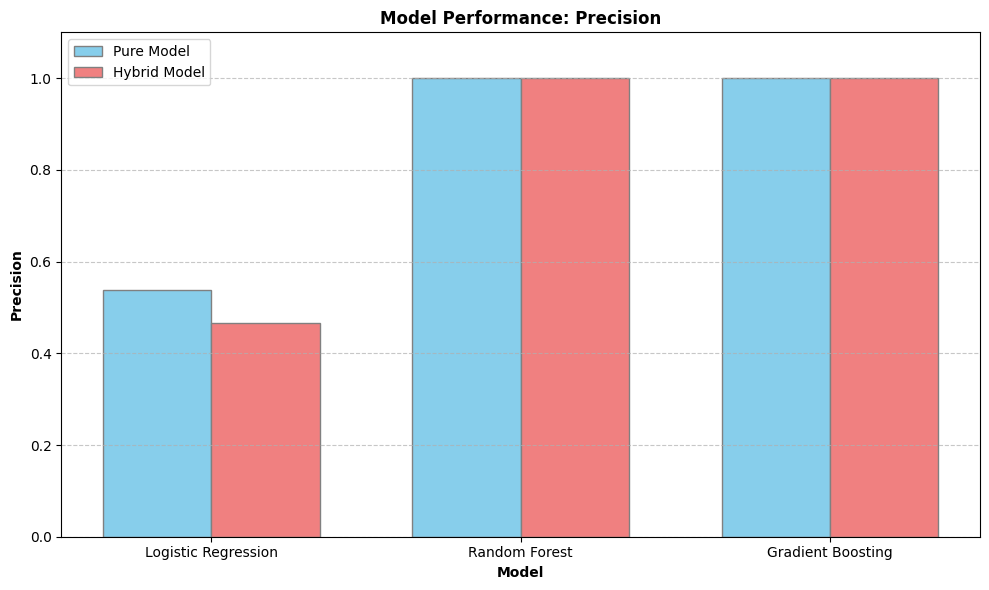

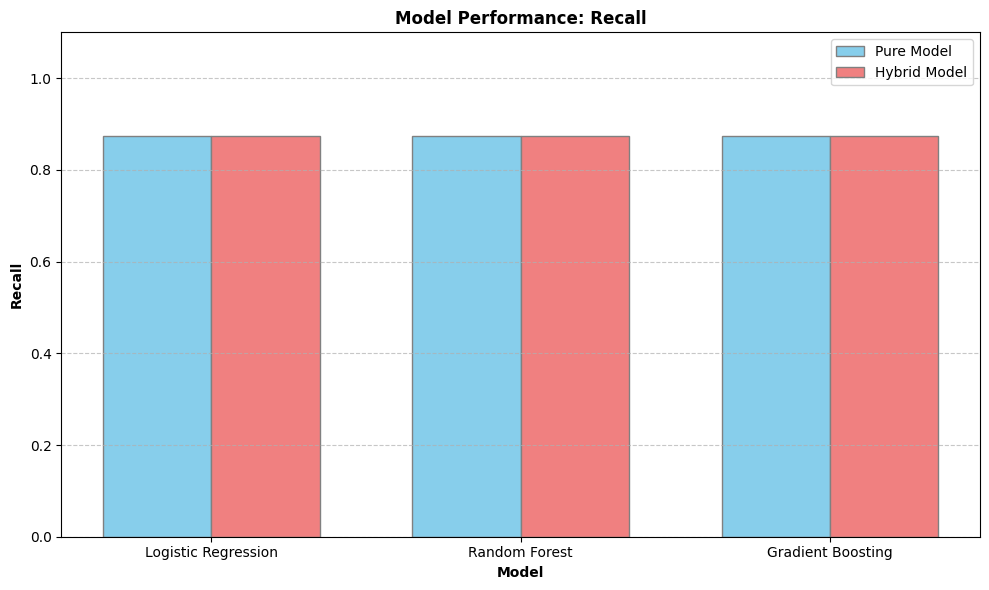

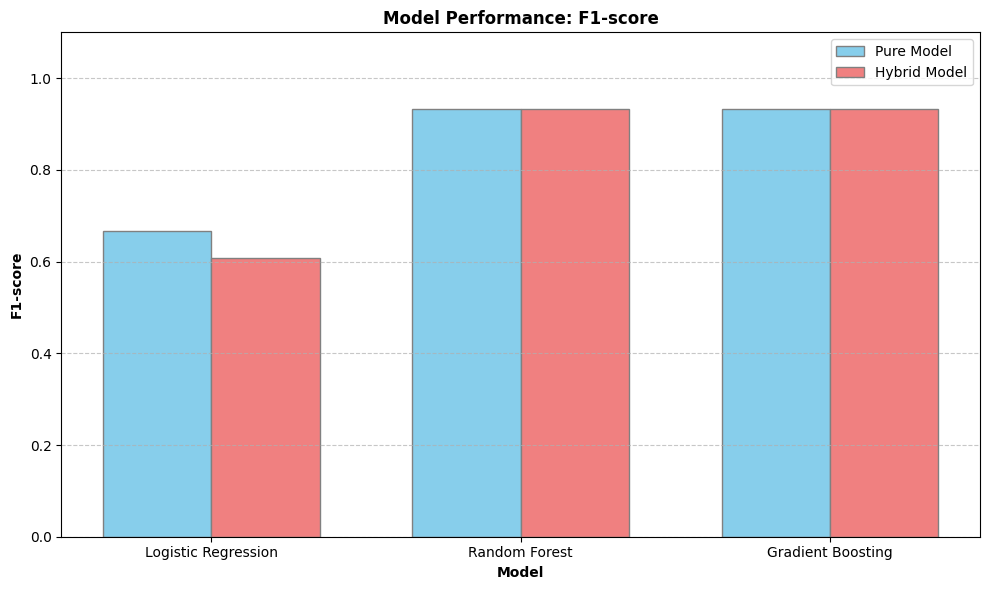

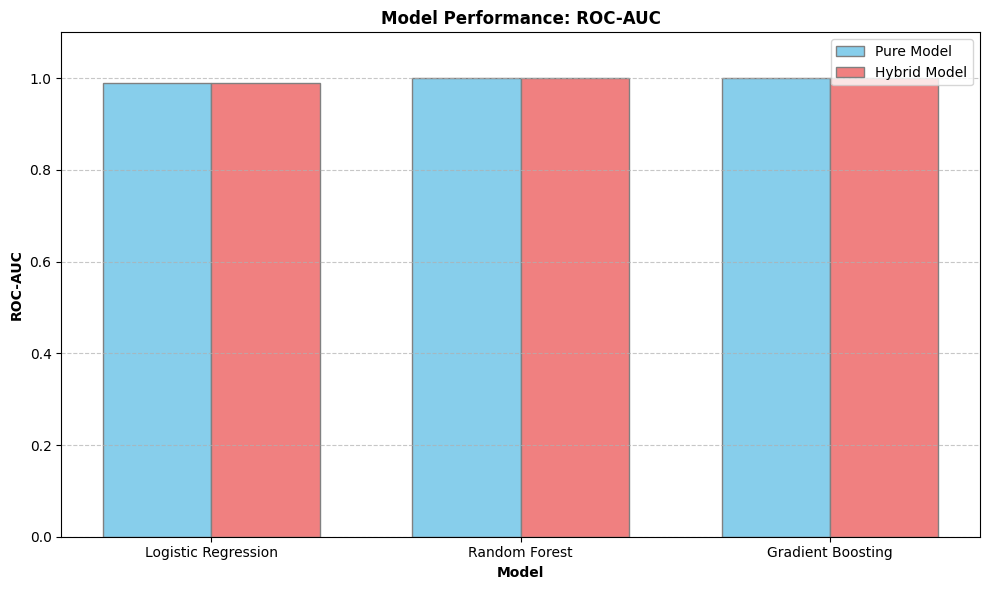

In [8]:
metrics_to_plot = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']
model_names = results_df['Model'].unique()

# Set the width of the bars
bar_width = 0.35

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get the data for 'Pure' and 'Hybrid' models for the current metric
    pure_scores = results_df[results_df['Type'] == 'Pure'][metric].values
    hybrid_scores = results_df[results_df['Type'] == 'Hybrid'][metric].values

    # Set the positions of the bars on the x-axis
    r1 = range(len(model_names))
    r2 = [x + bar_width for x in r1]

    # Create the bars
    ax.bar(r1, pure_scores, color='skyblue', width=bar_width, edgecolor='grey', label='Pure Model')
    ax.bar(r2, hybrid_scores, color='lightcoral', width=bar_width, edgecolor='grey', label='Hybrid Model')

    # Add labels, title, and legend
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'Model Performance: {metric}', fontweight='bold')
    ax.set_xticks([r + bar_width/2 for r in range(len(model_names))])
    ax.set_xticklabels(model_names)
    ax.legend()

    # Set y-axis limit appropriately (0 to 1 for these metrics)
    ax.set_ylim(0, 1.1)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Final Task

### Subtask:
Summarize the findings, clearly indicating which approach (pure supervised learning or the hybrid model incorporating anomaly scores) performed better and why, based on the evaluation metrics. Provide key insights from the analysis.


## Summary:

### Q&A
1.  **Which approach performed better (pure supervised learning or the hybrid model incorporating anomaly scores)?**
    For Random Forest and Gradient Boosting, both the pure supervised learning approach and the hybrid model (incorporating anomaly scores) performed identically and exceptionally well. For Logistic Regression, the pure supervised learning approach performed slightly better in terms of Precision and F1-score compared to the hybrid model.

2.  **Why, based on the evaluation metrics?**
    *   **Random Forest and Gradient Boosting:** Both models achieved a perfect Precision of 1.0000, Recall of 0.8750, F1-score of 0.9333, and ROC-AUC of 1.0000 in both pure and hybrid configurations. This indicates that the addition of the Isolation Forest anomaly score did not provide additional discriminative power for these robust tree-based models, as they were already capable of effectively identifying fraudulent transactions with very high accuracy and no false positives.
    *   **Logistic Regression:** The pure Logistic Regression model achieved a Precision of 0.5385 and an F1-score of 0.6667. In contrast, the hybrid Logistic Regression model showed a slightly lower Precision of 0.4667 and an F1-score of 0.6087. While Recall remained constant at 0.8750 and ROC-AUC was marginally higher (0.9887 vs. 0.9886) for the hybrid, the decrease in Precision and F1-score suggests that for this simpler model, the anomaly score feature might have introduced noise or led to a higher rate of false positives.

### Data Analysis Key Findings
*   The initial dataset of 10,000 rows exhibited a severe class imbalance, with only 38 fraudulent transactions (class 1) compared to 9962 legitimate ones (class 0).
*   SMOTE (Synthetic Minority Over-sampling Technique) successfully balanced the training data for both pure and hybrid approaches, ensuring fair model training.
*   Isolation Forest anomaly scores were successfully generated and integrated as an additional feature, increasing the feature count from 30 to 31 for the hybrid models.
*   **Superior Performance of Tree-based Models:** Random Forest and Gradient Boosting models consistently outperformed Logistic Regression. For both pure and hybrid approaches, these models achieved perfect Precision (1.0000) and ROC-AUC (1.0000), along with high Recall (0.8750) and F1-score (0.9333).
*   **Limited Impact of Hybrid Approach:** For Random Forest and Gradient Boosting, the incorporation of Isolation Forest anomaly scores did not lead to any change in performance metrics, indicating that these models were already robust enough to learn the underlying patterns without this additional feature.
*   **Slight Deterioration for Logistic Regression:** The hybrid approach slightly negatively impacted Logistic Regression's performance metrics relevant to fraud detection. Its Precision decreased from 0.5385 to 0.4667, and its F1-score dropped from 0.6667 to 0.6087, although Recall remained constant.

### Insights or Next Steps
*   For credit card fraud detection on this dataset, sophisticated tree-based models like Random Forest and Gradient Boosting are highly effective, demonstrating near-perfect precision in identifying fraudulent transactions. The addition of unsupervised anomaly scores from Isolation Forest did not provide a significant performance boost for these models.
*   Future work could investigate different anomaly detection algorithms or feature engineering techniques to create more impactful hybrid features, especially for simpler models like Logistic Regression, or explore the feature importance of the anomaly score in tree-based models to understand its contribution (or lack thereof).
